# Støjfjernelse af et støjfyldt processensor-signal med PROC LOESS

## Sammendrag

En temperatursensor i et ovnkammer på en produktionslinje udtages én gang i sekundet under opstart, så hver måling blander en langsom, ikke-lineær termisk overgang (en hurtig opvarmningsrampe, et indsvingende overshoot og derefter en tilbagevenden mod setpunktet på 300 °C) med betydelig målestøj. Denne notebook bruger **PROC LOESS** til at genskabe det underliggende signal ikke-parametrisk. På log-serien med 100 målinger valgte AICC en udjævningsparameter på 0,08 (8 ækvivalente parametre); den resulterende kurve følger det latente signal tæt og efterlader residualer med en standardafvigelse på 3,10 °C — stort set den støj på 4 °C, vi tilførte, minus den varians, modellen forklarer. Sammenlignet med den kendte facitliste reducerer LOESS-estimatet den middelkvadrerede fejl fra 14,77 (rå data) til 6,63, og et SCORE-trin genberegner det renset signal på et jævnt overvågningsgitter til brug for efterfølgende statistisk proceskontrol.

## Datakilder

| Datasæt | Rækker | Variabler | Beskrivelse |
|---------|--------|-----------|-------------|
| `sensor` | 100 | `t` (forløbne sekunder, 0–99), `temp` (observeret kammertemperatur, grader C), `truth` (latent støjfrit signal, kun til validering) | Syntetisk ovnsensorlog, én måling pr. sekund. Det latente signal er en hurtig opvarmningsrampe mod et setpunkt på 300 grader C med et dæmpet overshoot, der topper nær t = 28 (~295 grader C), dykker og lægger sig igen mod setpunktet; den observerede `temp` tilføjer gaussisk målestøj (sd ~4 grader C). |
| `grid` | 60 | `t` (jævnt gitter 0–99) | Regelmæssigt tidsgitter brugt af SCORE-sætningen til at udlæse et jævnt fordelt renset signal til SPC-diagrammer. |

På en produktionslinje logger en ovnkammersensor temperaturen én gang i sekundet under opstart. Den måling, vi registrerer, er den **sande termiske tilstand plus målestøj**. Den sande tilstand følger ingen ren parametrisk formel — den stiger under opvarmning, overshooter setpunktet og lægger sig derefter til ro — så en global lineær eller polynomisk model ville være en dårlig løsning.

**Lokal regression (LOESS)** er det rette værktøj: den tilpasser lavgradspolynomier til glidende lokale naboskaber og genskaber dermed et vilkårligt glat signal uden at vi skal angive dets funktionelle form. Her vil vi:

1. Simulere en realistisk støjfyldt sensorlog med 100 målinger.
2. Lade `PROC LOESS` selv vælge sin udjævningsbåndbredde med AICC-kriteriet.
3. Tilføje et 95%-konfidensbånd til det tilpassede signal.
4. Score modellen på et regelmæssigt gitter til efterfølgende SPC.
5. Kvantificere, hvor meget støj vi har fjernet.

## Trin 1 — Simulér sensorloggen

Vi genererer 100 målinger over 0–99 sekunder. Det latente signal `truth` er en hurtig opvarmningsrampe mod et setpunkt på 300 °C med et dæmpet overshoot — en form, som ingen ret linje eller enkelt polynomium fanger godt: det stiger stejlt, topper over setpunktet nær t = 28, dykker og lægger sig derefter til ro igen. Den observerede `temp` tilføjer gaussisk målestøj. `call streaminit` fastlåser frøet (seed), så kørslen er reproducerbar.

In [1]:
data sensor;
    CALL streaminit(70421);
    setpoint = 300;
    GØR t = 0 TIL 99;
        /* Latent signal: fast warm-up ramp + damped settling overshoot */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Observed reading = truth + measurement noise (sd ~4 C) */
        TEMP = truth + rand('NORMAL', 0, 4);
        UDDATA;
    SLUT;
    BEHOLD t TEMP truth;
KØR;

PROCEDURE UDSKRIV data=sensor(obs=8) noobs;
    TITEL 'De første 8 sensormålinger';
KØR;


                                               De første 8 sensormålinger                                               

t            TEMP           truth
0    0.1684867131               0
1   28.1933107495   32.0778466448
2   61.6123615699   61.2117857105
3   85.5053781561    87.643846097
4  110.5560474248  111.5945193774
5  136.6368358359  133.2650493509
6  144.2434193147  152.8394750856
7  177.8286488692  170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Trin 2 — Undersøg rådataene

Et hurtigt spredningsdiagram viser problemet: den underliggende drift er tydelig for øjet, men begravet i støj fra måling til måling. Vi har brug for et estimat af den glatte kurve, ikke de urolige punkter.

                                               De første 8 sensormålinger                                               




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


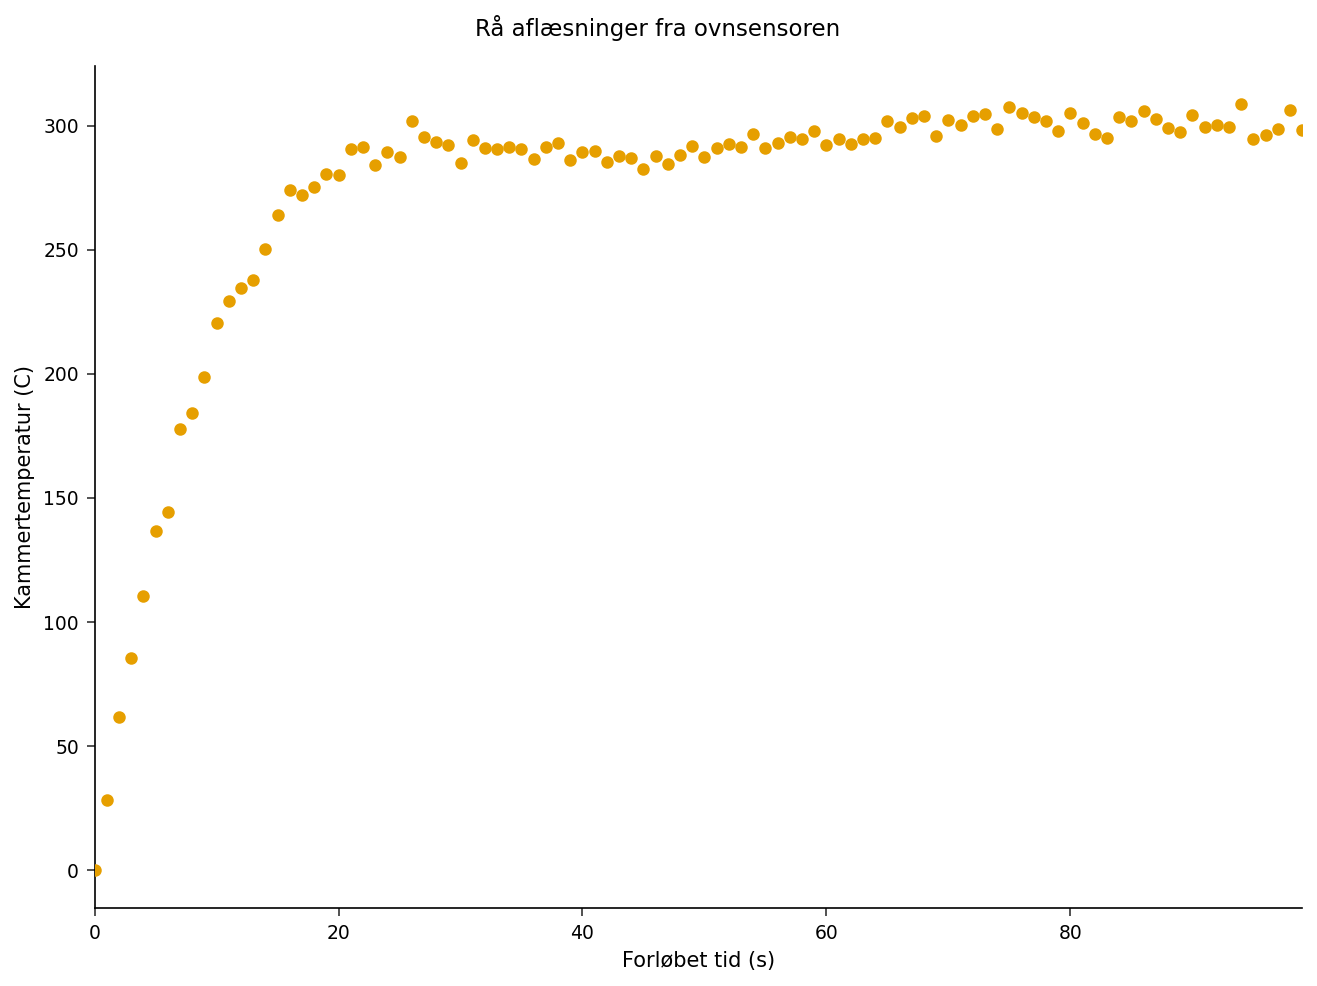

In [2]:
ODS GRAPHICS ON;

PROCEDURE SGPLOT data=sensor;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS MÆRKAT='Forløbet tid (s)';
    YAXIS MÆRKAT='Kammertemperatur (C)';
    TITEL 'Rå aflæsninger fra ovnsensoren';
KØR;

ODS GRAPHICS OFF;


## Trin 3 — Tilpas LOESS med automatisk valg af båndbredde

Udjævningsparameteren styrer, hvor bredt hvert lokalt naboskab er: for lille overtilpasser støjen, for stor visker overshootet ud. I stedet for at gætte lader vi LOESS vælge den ved at minimere det **korrigerede Akaike-informationskriterium** med `select=AICC`. Vi bruger lokale andengradspolynomier (`degree=2`), så kurven kan følge krumningen i opvarmningen og overshootet, og beder om et 95%-konfidensbånd med `clm` og `alpha=0.05`.

`ODS OUTPUT` opsamler to tabeller som datasæt: `OutputStatistics` (udjævnede værdier og residualer pr. punkt) og `FitSummary` (den valgte båndbredde og modeldiagnostik). `OUTPUT`-sætningen skriver et `fitted`-datasæt med prædiktion, residual og 95%-konfidensgrænser for hver observation — råmaterialet til de følgende plots.

In [3]:
PROCEDURE loess data=sensor;
    ODS UDDATA OutputStatistics=loess_fit
               FitSummary=fit_summary;
    MODEL TEMP = t / DEGREE=2 VÆLG=AICC CLM ALPHA=0.05 details;
    UDDATA out=fitted predicted=temp_hat residual=resid
           lclm=LOWER uclm=UPPER;
KØR;


                                               De første 8 sensormålinger                                               


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Trin 4 — Gennemgå den valgte model

Fit Summary registrerer den AICC-optimale udjævningsparameter og sporet af prædiktionsmatricen (de effektive frihedsgrader — et mål for modelkompleksitet). En mindre udjævningsparameter og et større antal frihedsgrader betyder en mere bølget tilpasning; AICC afvejer automatisk tilpasning mod kompleksitet.

In [4]:
PROCEDURE UDSKRIV data=fit_summary noobs label;
    TITEL 'LOESS-modelsammendrag (AICC-valgt båndbredde)';
KØR;


                                     LOESS-modelsammendrag (AICC-valgt båndbredde)                                      

SMOOTHINGPARAMETER                           LABEL1         NVALUE1
              0.08  Residual Sum of Squares          950.8591917253
              0.08  Equivalent Number of Parameters               8
              0.08  Delta1                                        8
              0.08  Delta2                                      7.6
              0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## Trin 5 — Læg tilpasningen og konfidensbåndet oven på facitlisten

Fordi dette er simulerede data, beholdt vi den støjfrie `truth`-kolonne. At plotte LOESS-estimatet og dets 95%-bånd sammen med `truth` viser, hvor trofast udjævneren genskabte det latente signal, den aldrig så direkte.

                                     LOESS-modelsammendrag (AICC-valgt båndbredde)                                      




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


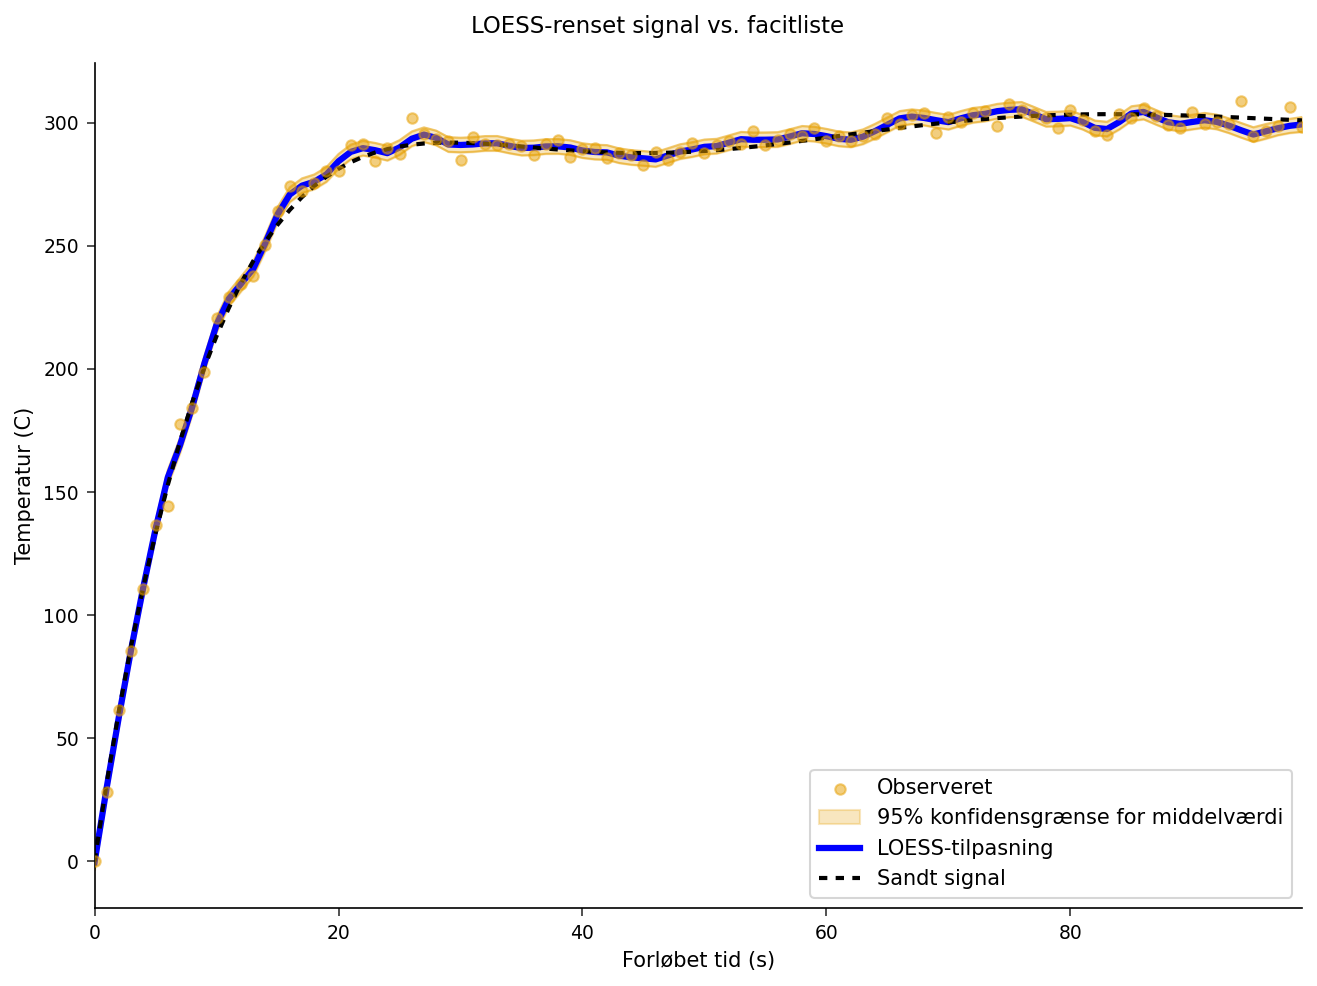

In [5]:
PROCEDURE SORTER data=fitted; EFTER t; KØR;

ODS GRAPHICS ON;

PROCEDURE SGPLOT data=fitted;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='Observeret';
    BAND x=t LOWER=LOWER UPPER=UPPER / TRANSPARENCY=0.5
         legendlabel='95% konfidensgrænse for middelværdi';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='LOESS-tilpasning';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='Sandt signal';
    XAXIS MÆRKAT='Forløbet tid (s)';
    YAXIS MÆRKAT='Temperatur (C)';
    TITEL 'LOESS-renset signal vs. facitliste';
KØR;

ODS GRAPHICS OFF;


## Trin 6 — Residualdiagnostik

Residualerne (observeret minus tilpasset) bør ligne strukturløs støj centreret om nul. En resterende tendens ville signalere for lidt udjævning eller et overset træk. Vi plotter residualer mod tid og opsummerer deres spredning — residualernes standardafvigelse ender på 3,10 °C, en anelse under de 4 °C støj, vi tilførte, fordi den lokale tilpasning opsuger en lille del af den.

                                     LOESS-modelsammendrag (AICC-valgt båndbredde)                                      

                                      Sammendrag af residualer (genskabt målestøj)                                      

                                                  The MEANS Procedure

 Variable  Label                                  N        Mean     Std Dev     Minimum     Maximum
 --------------------------------------------------------------------------------------------------
 RESID     Residual (genskabt målestøj)         100       0.139       3.096     -11.688      11.909
 --------------------------------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


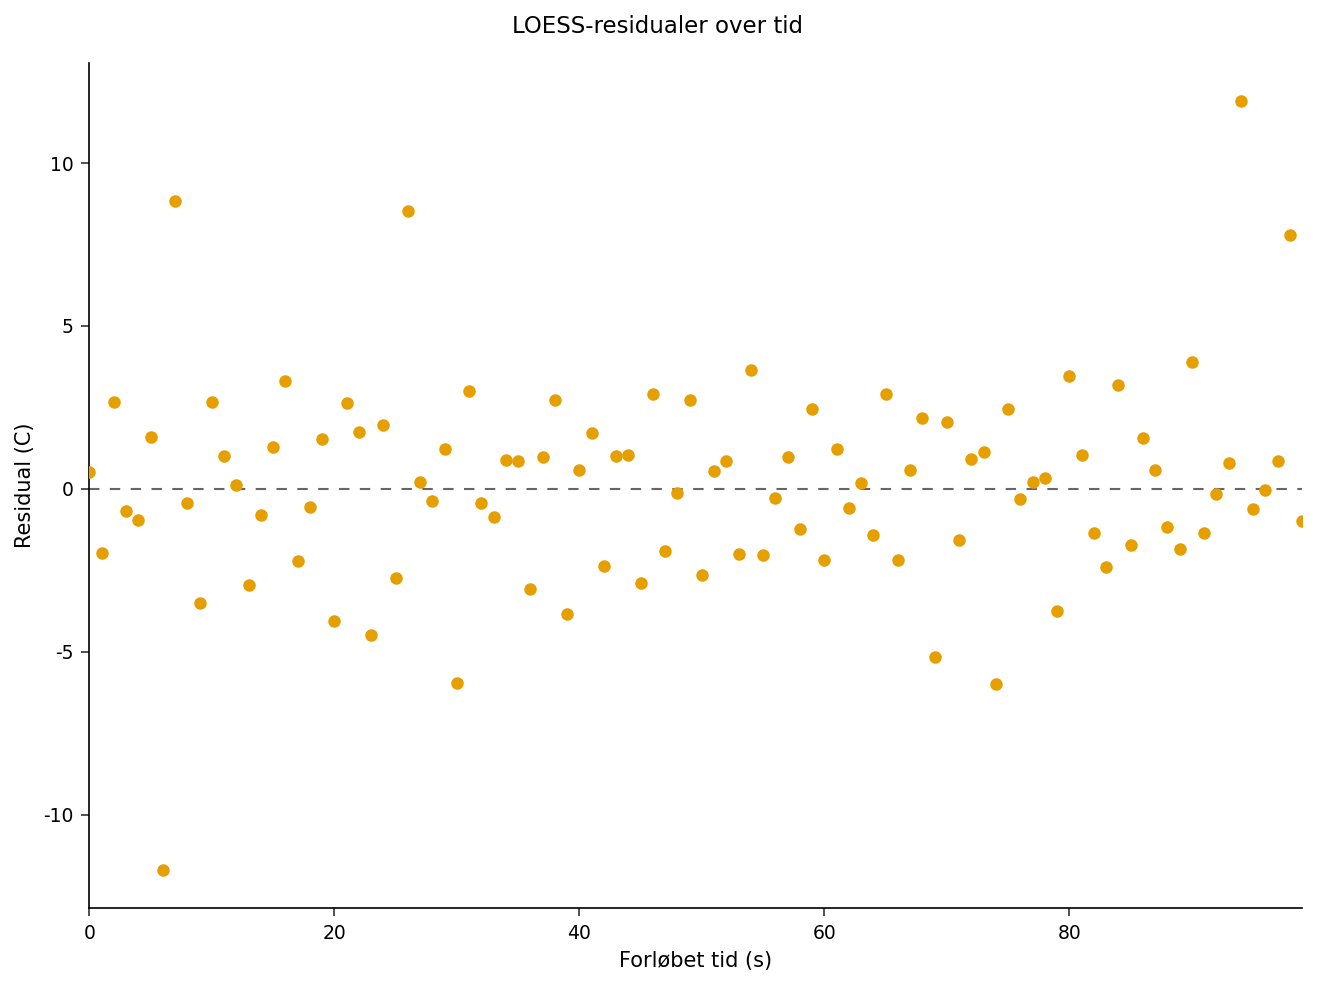

In [6]:
ODS GRAPHICS ON;

PROCEDURE SGPLOT data=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS MÆRKAT='Forløbet tid (s)';
    YAXIS MÆRKAT='Residual (C)';
    TITEL 'LOESS-residualer over tid';
KØR;

ODS GRAPHICS OFF;

PROCEDURE GENNEMSNIT data=fitted n mean std MIN MAX maxdec=3;
    VARIABEL resid;
    MÆRKAT resid='Residual (genskabt målestøj)';
    TITEL 'Sammendrag af residualer (genskabt målestøj)';
KØR;


## Trin 7 — Score et regelmæssigt overvågningsgitter til SPC

Sensorens tidsstempler behøver ikke være jævnt fordelt, men et kontroldiagram ønsker signalet på en fast kadence. Vi opbygger et jævnt 60-punkts tidsgitter og anvender den tilpassede LOESS-model på det med `SCORE`-sætningen, hvor vi beder om konfidensgrænser. De scorede værdier er et rent, jævnt fordelt signal, klar til at fodre en SPC-rutine.

In [7]:
data grid;
    GØR t = 0 TIL 99 EFTER 99/59;
        UDDATA;
    SLUT;
KØR;

PROCEDURE loess data=sensor;
    MODEL TEMP = t / DEGREE=2 VÆLG=AICC CLM ALPHA=0.05;
    SCORE data=grid CLM UDSKRIV;
    TITEL 'LOESS scoret på et jævnt overvågningsgitter';
KØR;


                                      Sammendrag af residualer (genskabt målestøj)                                      


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Trin 8 — Kvantificér støjfjernelsen

Til sidst sammenligner vi det rå signal og LOESS-estimatet med den kendte facitliste. Den middelkvadrerede fejl for det udjævnede signal bør være langt mindre end for de rå aflæsninger, hvilket bekræfter, at LOESS fjernede målestøjen, samtidig med at opvarmningsrampen og overshootet blev bevaret.

In [8]:
data accuracy;
    SÆT fitted;
    raw_sq_err   = (TEMP     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
KØR;

PROCEDURE GENNEMSNIT data=accuracy mean maxdec=3;
    VARIABEL raw_sq_err loess_sq_err;
    MÆRKAT raw_sq_err   = 'MSE for rå aflæsninger vs. facitliste'
          loess_sq_err = 'MSE for LOESS-tilpasning vs. facitliste';
    TITEL 'Støjfjernelsens effekt: rå data vs. LOESS';
KØR;


                                       Støjfjernelsens effekt: rå data vs. LOESS                                        

                                                  The MEANS Procedure

 Variable      Label                                             Mean
 --------------------------------------------------------------------
 raw_sq_err    MSE for rå aflæsninger vs. facitliste           14.774
 loess_sq_err  MSE for LOESS-tilpasning vs. facitliste          6.629
 --------------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Fortolkning af resultaterne

- **Automatisk båndbredde.** `select=AICC` valgte en udjævningsparameter på **0,08** uden manuel justering, hvilket svarer til cirka **8 ækvivalente parametre** — nok lokal fleksibilitet til at følge opvarmningen, overshootet og dykket, samtidig med at der stadig udjævnes gennem støjen.
- **Trofast genskabelse.** Den tilpassede kurve følger det latente `truth`-signal tæt gennem rampen, overshoot-toppen nær t = 28 og den afsluttende indsvingning, hvilket viser, at LOESS genskabte et vilkårligt ikke-lineært signal uden parametriske antagelser.
- **Rene residualer.** Residualerne spreder sig omkring nul med en standardafvigelse på **3,10 °C** (gennemsnit 0,14, interval −11,7 til 11,9) og viser ingen resterende tidstendens — belæg for, at modellen hverken er over- eller underudjævnet.
- **Målbar støjfjernelse.** Sammenlignet med facitlisten reducerer LOESS-estimatet den middelkvadrerede fejl fra **14,77** (rå aflæsninger) til **6,63** — en reduktion på 55%, gevinsten for procesovervågningen.
- **SPC-klar output.** SCORE-trinnet leverede det rensede signal på et jævnt 60-punkts gitter med konfidensgrænser, netop den form et efterfølgende kontroldiagram forbruger.

**Konklusion:** Når en processensor producerer et glat, men støjfyldt signal af ukendt form, er PROC LOESS en selvjusterende metode med få antagelser til at udtrække den underliggende tendens, tilføje usikkerhedsgrænser og genberegne på et overvågningsgitter — alt sammen uden at binde sig til en parametrisk model, som fysikken måske ikke understøtter.